標準差: cavity_press, cavity_temp, etalon_temp, (過去1 分鐘或5分鐘)
偏離目標值: delta 值 ，譬如cavity_press
outlet_valve 前後差分? 閥門劇烈開關 = 進氣不穩定
壓力閥門比值
溫度差: cavity_temp - warmbox_temp
        warmbox_temp - das_temp

        雜訊比特徵? Co2_N / Co2_Nfiltered
        累積誤差 co2_target_error?
        cycle_time 變長

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV


parquet_filename ='../data/processed/tac_co2_processed_v1.parquet'

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)

In [3]:
def get_data_by_year(file_path, year_list):
    df = pd.read_parquet(file_path, filters=[('year', 'in', year_list)])
    return df

def fill_Nan(df, feature_col):
    df = df.copy()
    for i in feature_col:
        df[i] = df[i].ffill().fillna(0)
    return df

def best_threshold(X_test, model, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * (precisions *recalls) / (precisions + recalls+ 1e-7) # 1e-7 to prevent Nan

    best_idx = np.argmax(f1_scores[:-1])
    best_thres = thresholds[best_idx]

    print(f"Best threshold: {best_thres}")
    print(f"Best F1-score: {f1_scores[best_idx]:.4f}")
    print(f'Precision"{precisions[best_idx]:.4f}", Recall:{recalls[best_idx]}')
   
def plot_importance(model, feature_names, title_suffix=""):
    """
    plotting Feature importance, and upload to MLflow automatically
    """
    print
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values()

    fig, ax = plt.subplots(figsize=(10, 15))
    importances.plot(kind='barh', ax=ax)

    title = f'Feature Importance ({title_suffix})' if title_suffix else "Feature Importance"
    ax.set_title(title)
    fig.tight_layout()

    plt.show()
    plt.close(fig)


def random_forest_model(X_train, y_train, X_test, y_test, feature_names, 
                        experiment_run_name='RF_Model',n_estimators=200, 
                        max_depth=12, n_jobs=-1, threshold=0.5, class_weight=None):
    """
    Fits and evaluate ML models.
    models: dictionary of different ML models
    X_train: training data (no labels)
    X_test: testinh data (no labels)
    y_train: training labels
    y_test: testing labels
    returns model scores dictionary
    """

    model = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth = max_depth,
    random_state=42,
    n_jobs = n_jobs,
    class_weight=class_weight)


    model.fit(X_train, y_train)

    # evaluation and recording Metrics
    y_proba = model.predict_proba(X_test)[:, 1]
    #y_pred = model.predict(X_test)
    y_pred = (y_proba > threshold).astype(int) # threshold should be 0.05 or something
    
    acc = accuracy_score(y_test, y_pred)

    print("Model training completed!")
    print(classification_report(y_test, y_pred))

    cm =confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax =plt.subplots(figsize=(6,6))
    disp.plot(ax=ax,cmap=plt.cm.Blues)
    plt.title(f'Normalized Confusion Matrix, threshold:{threshold}')
    # upload figure to mlflow
    plot_path = f'image/0626_confusion_matrix_{threshold}.png' # to produce the real confusion matrix plot to cover the mlflow autolog's(threshold=0.5 default) 
    plt.savefig(plot_path)
    plt.close()
    print(model.feature_importances_)
    return model
    #plot_importance(model, feature_names, title_suffix=experiment_run_name)

In [4]:
def diff_gen(df, feature, period):
    df[f'{feature}_diff_{period}'] = (df[f'{feature}'].diff(period)).fillna(0)

    return df

def ratio_featutre_gen(df):
    df['warmbox_temp_cavity_temp_ratio'] = df['warmbox_temp']/df['cavity_temp']

    fill_feature_ratio = ['warmbox_temp_cavity_temp_ratio']
    for i in fill_feature_ratio :
        df[i] = df[i].fillna(0)
    return df

def lag_gen (df, feature, period):
    df[f'{feature}_lag_{period}'] = (df[f'{feature}'].shift(period)).fillna(0)
    return df


def rolling_std_gen ( df, feature, period):
    df[f'{feature}_roll_std_{period}'] = (df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').std()).fillna(0)# self not included, NAN->0
    return df

def rolling_mean_residual_gen( df, feature, period):
    df[f'{feature}_roll_mean_{period}'] = df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').mean().fillna(0) # self not included
    df[f'{feature}_residual_{period}'] = df[f'{feature}']- df[f'{feature}_roll_mean_{period}']# self not included
    return df

def feature_eng_apply( df, config):
    for opt, params in config.items():
        cols = params['cols']
        period = params.get('period') or params.get('periods', 1) # period's value -> periods's -> 1

        for feature in cols:
            if opt == 'diff':
                df = diff_gen(df, feature, period)
            elif opt == 'lag':
                df = lag_gen(df, feature, period)
            elif opt == 'roll_std':
                df = rolling_std_gen( df, feature, period)
            elif opt == 'roll_mean_res':
                df = rolling_mean_residual_gen(df, feature, period)
    return df 

In [5]:
feature_cols= [ 
         #'co2_dry','co2_wet', 
        'co2_target_error',  #'co2_C',         'co2_N',     
        'co2_Cdrift', 'co2_Nfiltered', 
       'cycle_time', 'h2o', 'cavity_press', 'cavity_temp',
       'das_temp', 'etalon_temp', 'warmbox_temp', 'outlet_valve', 'datetime'
       #'label1'
]

feature_config ={
    'diff':{'cols': [ 'warmbox_temp','cavity_temp',
                     'das_temp','cycle_time'], 'periods':1},
    'lag':{'cols':['cycle_time'], 'periods':1},

    'roll_std':{'cols': ['cavity_press', 'cavity_temp',
       'das_temp', 'etalon_temp', 'warmbox_temp'], 'period':'5min'},
    'roll_mean_res':{'cols':['cycle_time'], 'period': '5min'}
}

In [6]:
train_years = list(range(2012, 2017))
test_years = [2017, 2018]

data_train = get_data_by_year(parquet_filename, train_years)
data_test = get_data_by_year(parquet_filename, test_years)
data_train['datetime'] = pd.to_datetime(data_train['datetime'])
data_test['datetime'] = pd.to_datetime(data_test['datetime'])

In [7]:
X_train = data_train[feature_cols]
y_train = data_train['label1']


X_test = data_test[feature_cols]
y_test = data_test['label1']

X_train_final = fill_Nan(X_train, feature_cols)
X_test_final= fill_Nan(X_test, feature_cols)

X_train_final['datetime'] = pd.to_datetime(X_train_final['datetime'])
X_test_final['datetime'] = pd.to_datetime(X_test_final['datetime'])

X_train_final = X_train_final.set_index('datetime').sort_index()
X_test_final = X_test_final.set_index('datetime').sort_index()

y_train.index= X_train_final.index
y_test.index =X_test_final.index

In [8]:
data_train['year'].unique()

array([2012, 2013, 2014, 2015, 2016], dtype=int32)

In [9]:
X_train_final  = ratio_featutre_gen(X_train_final)
X_test_final= ratio_featutre_gen(X_test_final)

# conver date index as pd datatime type

X_train_final= feature_eng_apply(X_train_final, feature_config)
X_test_final= feature_eng_apply(X_test_final, feature_config)

In [10]:
X_train_final.head()

,co2_target_error,co2_Cdrift,co2_Nfiltered,cycle_time,h2o,cavity_press,cavity_temp,das_temp,etalon_temp,warmbox_temp,outlet_valve,warmbox_temp_cavity_temp_ratio,warmbox_temp_diff_1,cavity_temp_diff_1,das_temp_diff_1,cycle_time_diff_1,cycle_time_lag_1,cavity_press_roll_std_5min,cavity_temp_roll_std_5min,das_temp_roll_std_5min,etalon_temp_roll_std_5min,warmbox_temp_roll_std_5min,cycle_time_roll_mean_5min,cycle_time_residual_5min
datetime,,,,,,,,,,,,,,,,,,,,,,,,
2012-01-11 16:27:30,0.0,406.303,100.0,3.733,-0.02232,140.005249,44.902771,32.141670,44.770721,0.0,31442.617188,0.0,0.0,0.000000,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.0,0.000,3.733
2012-01-11 16:28:30,0.0,405.779,100.0,3.733,-0.02232,140.004349,44.929520,32.362499,44.918819,0.0,31543.970703,0.0,0.0,0.026749,0.220829,0.000,3.733,0.000000,0.000000,0.000000,0.000000,0.0,3.733,0.000
2012-01-11 16:29:30,0.0,403.813,100.0,3.733,-0.02243,140.005127,44.933521,32.597919,44.997021,0.0,31626.548828,0.0,0.0,0.004002,0.235420,0.000,3.733,0.000637,0.018914,0.156150,0.104721,0.0,3.733,0.000
2012-01-11 16:30:30,0.0,404.580,100.0,3.733,-0.02217,140.007446,44.926159,32.815060,45.025490,0.0,31687.378906,0.0,0.0,-0.007362,0.217140,0.000,3.733,0.000488,0.016719,0.228164,0.114935,0.0,3.733,0.000
2012-01-11 16:31:30,0.0,404.304,100.0,3.625,-0.02259,140.003143,44.919140,32.988129,45.024429,0.0,31726.804688,0.0,0.0,-0.007019,0.173069,-0.108,3.733,0.001330,0.013813,0.291228,0.114147,0.0,3.733,-0.108


In [11]:
model_features =['port', 'co2_target_error', 'co2_Cdrift', 'co2_N', 'co2_Nfiltered',
       'cycle_time', 'h2o', 'cavity_press', 'cavity_temp', 'das_temp',
       'etalon_temp', 'warmbox_temp', 'outlet_valve',
       'warmbox_temp_cavity_temp_ratio', 'warmbox_temp_diff_1',
       'cavity_temp_diff_1', 'das_temp_diff_1', 'cycle_time_diff_1',
       'cycle_time_lag_1', 'cavity_press_roll_std_5min',
       'cavity_temp_roll_std_5min', 'das_temp_roll_std_5min',
       'etalon_temp_roll_std_5min', 'warmbox_temp_roll_std_5min',
       'cycle_time_roll_mean_5min', 'cycle_time_residual_5min']

In [12]:
y_train.head()

datetime
2012-01-11 16:27:30    1.0
2012-01-11 16:28:30    1.0
2012-01-11 16:29:30    1.0
2012-01-11 16:30:30    1.0
2012-01-11 16:31:30    1.0
Name: label1, dtype: float32

Model training completed!
              precision    recall  f1-score   support

         0.0       0.94      0.87      0.90    818802
         1.0       0.47      0.65      0.55    141485

    accuracy                           0.84    960287
   macro avg       0.70      0.76      0.72    960287
weighted avg       0.87      0.84      0.85    960287

[1.84632240e-01 1.17594798e-02 6.28808615e-03 4.37917515e-02
 2.36066406e-02 2.41051553e-02 1.13164534e-03 9.40075839e-03
 1.88778753e-01 1.69750324e-02 5.58001062e-02 1.76408943e-02
 4.22180723e-04 2.80821555e-04 1.25198057e-04 1.39303879e-01
 6.76255147e-02 5.78411508e-02 2.21655782e-03 2.11099662e-04
 5.18507712e-04 7.17778295e-03 3.55855585e-02 1.04781206e-01]
Best threshold: 0.582183961583482
Best F1-score: 0.5814
Precision"0.6342", Recall:0.5367565466303849


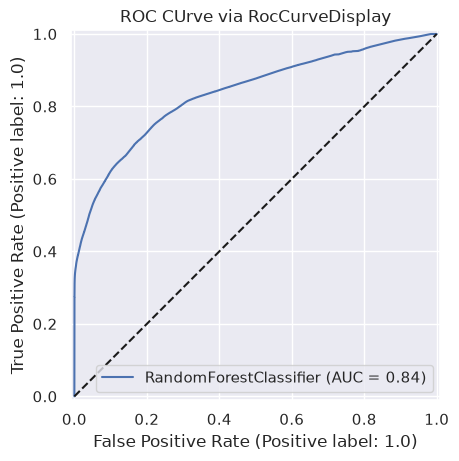

In [14]:

rf_model = random_forest_model(
        X_train_final, y_train, X_test_final,  y_test,
        feature_names=model_features,
        experiment_run_name=f'rf_first_test', n_estimators=100, max_depth=10, n_jobs=4,
        threshold=0.5,class_weight='balanced'
    )
best_threshold(X_test_final, rf_model, y_test)

RocCurveDisplay.from_estimator(rf_model, X_test_final, y_test)

plt.title('ROC CUrve via RocCurveDisplay')
plt.plot([0, 1], [0,1], 'k--')
plt.show()

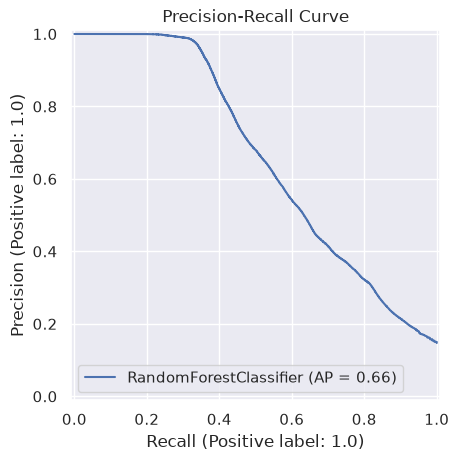

In [15]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(rf_model, X_test_final, y_test)

plt.title('Precision-Recall Curve')
plt.show()

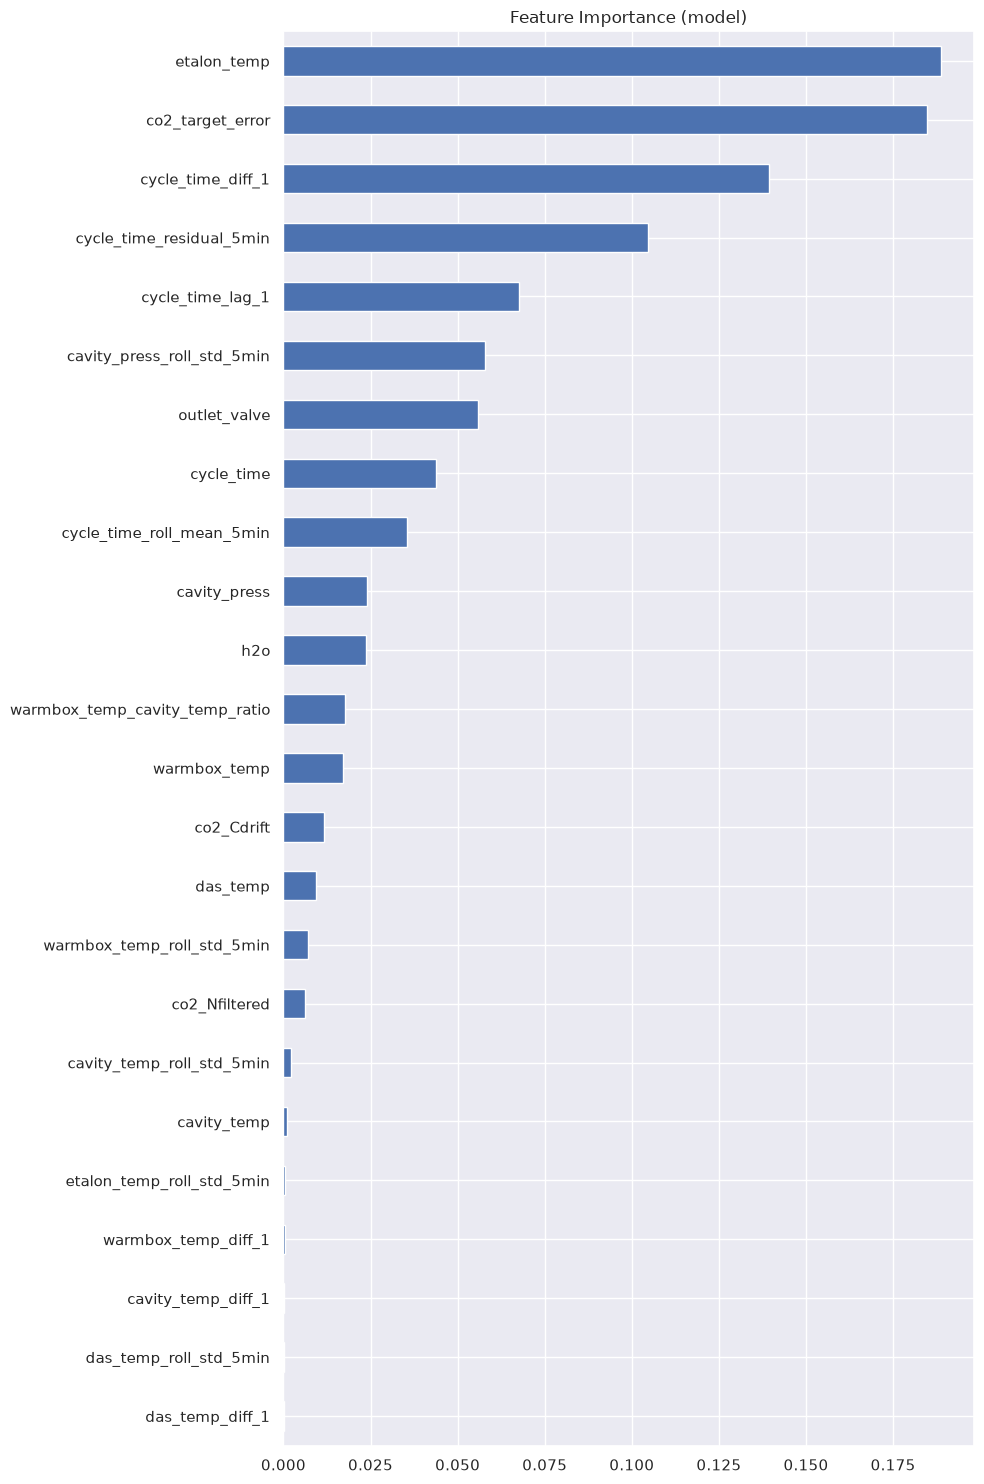

In [16]:
importances = pd.Series(rf_model.feature_importances_, index=X_train_final.columns)
importances = importances.sort_values()

fig, ax = plt.subplots(figsize=(10, 15))
importances.plot(kind='barh', ax=ax)

title = f'Feature Importance (model)'
ax.set_title(title)
fig.tight_layout()

plt.show()
plt.close(fig)